## Data Cleaning Overview

This notebook prepares the raw datasets for analysis by:

- Standardizing keys and formats across tables
- Handling missing and inconsistent values
- Correcting invalid values and reporting duplicate patterns
- Ensuring consistency between datasets before joining
- Validating data quality after each major transformation step

The goal is to create clean, reliable inputs for feature engineering and downstream analysis while keeping the cleaning process transparent and easy to audit.

## Environment Setup

This section connects to the persistent DuckDB database and configures the Python environment for inspection, transformation, and validation.

The database contains the raw source tables as well as the cleaned analytical tables created in this notebook.

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect("developer_project.duckdb")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

c:\Users\ldcal\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Validation Functions

To make the cleaning process transparent, this notebook validates the activity data after each major step.

The validation output includes:

- row counts
- missing value checks
- future date checks
- score range summaries
- duplicate reporting for records with and without `activity_id`
- category distribution checks when available

This makes it easier to compare the table before and after each transformation and confirm that the logic behaves as intended.

In [3]:
def show_query(title, query, limit=None):
    display(f"\n{title}")
    q = query if limit is None else f"{query}\nLIMIT {limit}"
    display(con.execute(q).fetchdf())


def validate_activity_table(table_name):
    display(f"\n{'='*80}")
    display(f"VALIDATION: {table_name}")
    display(f"{'='*80}")

    display("\nRow count:")
    display(con.execute(f"""
        SELECT COUNT(*) AS row_count
        FROM {table_name}
    """).fetchdf())

    display("\nNull / missing checks:")
    display(con.execute(f"""
        SELECT
            COUNT(*) AS total_rows,
            SUM(CASE WHEN dev_contact IS NULL OR TRIM(dev_contact) = '' THEN 1 ELSE 0 END) AS missing_dev_contact,
            SUM(CASE WHEN activity_date IS NULL THEN 1 ELSE 0 END) AS missing_activity_date,
            SUM(CASE WHEN activity_id IS NULL OR TRIM(activity_id) = '' THEN 1 ELSE 0 END) AS missing_activity_id,
            SUM(CASE WHEN activity_score IS NULL THEN 1 ELSE 0 END) AS missing_activity_score
        FROM {table_name}
    """).fetchdf())

    display("\nFuture date check:")
    display(con.execute(f"""
        SELECT COUNT(*) AS future_rows
        FROM {table_name}
        WHERE activity_date > CURRENT_DATE
    """).fetchdf())

    display("\nScore range check:")
    display(con.execute(f"""
        SELECT
            MIN(activity_score) AS min_score,
            MAX(activity_score) AS max_score,
            AVG(activity_score) AS avg_score,
            MEDIAN(activity_score) AS median_score
        FROM {table_name}
    """).fetchdf())

    display("\nDuplicate check using activity_id only when present:")
    display(con.execute(f"""
        SELECT COUNT(*) AS duplicate_activity_ids
        FROM (
            SELECT activity_id
            FROM {table_name}
            WHERE activity_id IS NOT NULL AND TRIM(activity_id) <> ''
            GROUP BY activity_id
            HAVING COUNT(*) > 1
        ) t
    """).fetchdf())

    display("\nFallback duplicate check for rows without activity_id:")
    display(con.execute(f"""
        SELECT COUNT(*) AS duplicate_null_id_groups
        FROM (
            SELECT
                dev_contact, activity_date, activity_name, activity_type, activity_role, activity_attendance
            FROM {table_name}
            WHERE activity_id IS NULL OR TRIM(activity_id) = ''
            GROUP BY
                dev_contact, activity_date, activity_name, activity_type, activity_role, activity_attendance
            HAVING COUNT(*) > 1
        ) t
    """).fetchdf())

    if "activity_category" in con.execute(f"DESCRIBE {table_name}").fetchdf()["column_name"].tolist():
        display("\nTop activity categories:")
        display(con.execute(f"""
            SELECT activity_category, COUNT(*) AS cnt
            FROM {table_name}
            GROUP BY activity_category
            ORDER BY cnt DESC
        """).fetchdf())

## Activity Score Mapping Preparation

Before cleaning the activity table, this notebook prepares the external activity score mapping file.

This mapping is used to standardize activity-related labels and provide fallback scoring logic for records whose original score is missing.

Key objectives in this section:

- load the raw score mapping file
- clean and normalize mapping fields
- validate the score range
- prepare a reusable lookup table for activity scoring

In [4]:
con.execute(""" 
CREATE OR REPLACE TABLE activity_score_mapping_raw AS 
SELECT * 
FROM read_csv_auto('Data/Activity_Score_Mapping.csv', header=True)
""")

con.execute("""
CREATE OR REPLACE TABLE activity_score_mapping_clean AS
SELECT DISTINCT
    LOWER(TRIM(COALESCE(object, 'unknown'))) AS object_name,
    LOWER(TRIM(COALESCE(field, 'unknown'))) AS field_name,
    LOWER(TRIM(COALESCE(value, 'unknown'))) AS field_value,
    COALESCE(TRY_CAST(score AS DOUBLE), 0.0) AS mapped_score
FROM activity_score_mapping_raw
""")

display("\nMapping validation:")
display(con.execute("""
SELECT
    COUNT(*) AS total_rows,
    MIN(mapped_score) AS min_score,
    MAX(mapped_score) AS max_score,
    SUM(CASE WHEN mapped_score < 0 THEN 1 ELSE 0 END) AS negative_scores,
    SUM(CASE WHEN mapped_score > 100 THEN 1 ELSE 0 END) AS over_100_scores
FROM activity_score_mapping_clean
""").fetchdf())

show_query(
    "Mapping preview",
    "SELECT * FROM activity_score_mapping_clean ORDER BY mapped_score DESC",
    limit=20
)

'\nMapping validation:'

,total_rows,min_score,max_score,negative_scores,over_100_scores
0,39,0.0,100.0,0.0,0.0


'\nMapping preview'

,object_name,field_name,field_value,mapped_score
0,dev event attendance,role,presenter/speaker,100.0
1,dev form,form type,testimonial,50.0
2,dev dli attendance,course type,instructor-led,40.0
3,dev dli attendance,course type,instructor-led remote,30.0
4,dev dli attendance,course type,self-paced online,20.0
5,dev forum activities,accepted date,true,15.0
6,dev event,event type,conference,10.0
7,dev event,event type,conference session,10.0
8,dev dli attendance,course type,third party,10.0
9,dev event attendance,status,attended live,10.0


## Activity Data Cleaning

The activity dataset is the main behavioral signal in this project. It captures developer engagement across trainings, webinars, events, downloads, forums, and other touchpoints.

Because this table is large and heterogeneous, cleaning focuses on:

- standardizing text fields
- normalizing naming inconsistencies
- improving activity scoring
- capping invalid score values
- preserving rows with null `activity_id`
- identifying and reporting duplicate patterns

The final output from this section is a cleaned and standardized activity table suitable for downstream feature engineering and behavioral analysis.

### Initial Activity Baseline

This step creates a stable base version of the activity dataset for inspection and validation.

The purpose of this table is to:

- preserve the raw cleaned source as a reference point
- cast key columns into usable types
- support before-and-after comparisons during later cleaning stages

In [5]:
con.execute("""
CREATE OR REPLACE TABLE activity_base AS
SELECT
    dev_contact,
    activity,
    activity_name,
    activity_type,
    activity_role,
    activity_attendance,
    TRY_CAST(activity_score AS DOUBLE) AS activity_score,
    CAST(activity_date AS DATE) AS activity_date,
    activity_id,
    filepath,
    pk1,
    pk2,
    lead_source,
    nvidia_campaign_id,
    gtc_nvidia_campaign_id,
    lead_source_details
FROM activity_clean
""")

validate_activity_table("activity_base")

show_query(
    "Before cleaning: sample raw activity rows",
    "SELECT * FROM activity_base",
    limit=20
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

'\n================================================================================'

'VALIDATION: activity_base'

'================================================================================'

'\nRow count:'

...

'\nFallback duplicate check for rows without activity_id:'

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_null_id_groups
0,1


'\nBefore cleaning: sample raw activity rows'

,dev_contact,activity,activity_name,activity_type,activity_role,activity_attendance,activity_score,activity_date,activity_id,filepath,pk1,pk2,lead_source,nvidia_campaign_id,gtc_nvidia_campaign_id,lead_source_details
0,6417584,DLI Training,Building RAG Agents with LLMs,Instructor-Led,Attendee,Attended Live,40.0,2025-11-12,1875418,None,1875418,course-v1:DLI+S-FX-15+V1-ZH,None,None,None,None
1,6752524,DLI Training,Getting Started with Deep Learning,Self-Paced Online,Attendee,Attended Live,20.0,2024-05-18,764222,None,764222,course-v1:DLI+S-FX-01+V1,None,None,None,None
2,6389272,DLI Training,(COURSE ENDING ON 7/1/24) High-Performance Com...,Self-Paced Online,Attendee,Attended Live,20.0,2024-04-17,736857,None,736857,course-v1:DLI+L-AC-25+V1-ZH,None,None,None,None
3,6763105,DLI Training,Getting Started with Deep Learning,Self-Paced Online,Attendee,Attended Live,20.0,2024-05-22,766590,None,766590,course-v1:DLI+S-FX-01+V1,None,None,None,None
4,6790671,DLI Training,Prompt Engineering with LLaMA-2 (Access Expire...,Self-Paced Online,Attendee,Attended Live,20.0,2024-05-30,774705,None,774705,course-v1:DLI+S-FX-12+V1,None,None,None,None
5,6784220,DLI Training,Getting Started with Deep Learning,Self-Paced Online,Attendee,Attended Live,20.0,2024-05-28,772702,None,772702,course-v1:DLI+S-FX-01+V1,None,None,None,None
6,6878366,DLI Training,Augment your LLM Using Retrieval Augmented Gen...,Self-Paced Online,Attendee,Attended Live,20.0,2024-06-19,798402,None,798402,course-v1:DLI+S-FX-16+V1,None,None,None,None
7,1257703,DLI Training,Data Augmentation and Segmentation with Genera...,Self-Paced Online,Attendee,Attended Live,20.0,2021-05-13,307474,None,307474,course-v1:DLI+L-HX-09+V1-ZH,None,None,None,None
8,6878674,DLI Training,Modeling Time Series Data with Recurrent Neura...,Self-Paced Online,Attendee,Attended Live,20.0,2024-06-19,798483,None,798483,course-v1:DLI+L-FX-24+V1,None,None,None,None
9,6785420,DLI Training,Building Real-Time Video AI Applications,Self-Paced Online,Attendee,Attended Live,20.0,2024-05-29,773063,None,773063,course-v1:DLI+S-IV-01+V1,None,None,None,None


### Stage 1: Normalize Raw Activity Fields

This step standardizes the raw activity fields to reduce inconsistent formatting across records.

Transformations include:

- trimming whitespace
- converting text to lowercase
- replacing missing text values with `"unknown"`
- collapsing repeated spaces
- standardizing `activity_id` blanks to null

Rows are filtered only when they are structurally unusable for analysis, such as missing developer identifiers or invalid activity dates.

In [6]:
show_query(
    "Before Stage 1: values likely needing normalization",
    """
    SELECT
        dev_contact,
        activity,
        activity_name,
        activity_type,
        activity_role,
        activity_attendance,
        lead_source
    FROM activity_base
    WHERE
        activity != LOWER(TRIM(activity))
        OR activity_name != LOWER(TRIM(activity_name))
        OR activity_type != LOWER(TRIM(activity_type))
        OR activity_role != LOWER(TRIM(activity_role))
        OR activity_attendance != LOWER(TRIM(activity_attendance))
        OR lead_source != LOWER(TRIM(lead_source))
    """,
    limit=500
)

con.execute("""
CREATE OR REPLACE TABLE activity_work AS
SELECT
    TRIM(dev_contact) AS dev_contact,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity, 'unknown')), '\s+', ' ')) AS activity,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_name, 'unknown')), '\s+', ' ')) AS activity_name,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_type, 'unknown')), '\s+', ' ')) AS activity_type,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_role, 'unknown')), '\s+', ' ')) AS activity_role,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_attendance, 'unknown')), '\s+', ' ')) AS activity_attendance,
    activity_score,
    activity_date,
    NULLIF(TRIM(activity_id), '') AS activity_id,
    filepath,
    pk1,
    pk2,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(lead_source, 'unknown')), '\s+', ' ')) AS lead_source,
    nvidia_campaign_id,
    gtc_nvidia_campaign_id,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(lead_source_details, 'unknown')), '\s+', ' ')) AS lead_source_details
FROM activity_base
WHERE dev_contact IS NOT NULL
  AND TRIM(dev_contact) <> ''
  AND activity_date IS NOT NULL
  AND activity_date <= CURRENT_DATE
""")

validate_activity_table("activity_work")

show_query(
    "After Stage 1: sample standardized rows",
    "SELECT * FROM activity_work",
    limit=20
)

'\nBefore Stage 1: values likely needing normalization'

,dev_contact,activity,activity_name,activity_type,activity_role,activity_attendance,lead_source
0,6417584,DLI Training,Building RAG Agents with LLMs,Instructor-Led,Attendee,Attended Live,NaN
1,6752524,DLI Training,Getting Started with Deep Learning,Self-Paced Online,Attendee,Attended Live,NaN
2,6389272,DLI Training,(COURSE ENDING ON 7/1/24) High-Performance Com...,Self-Paced Online,Attendee,Attended Live,NaN
3,6763105,DLI Training,Getting Started with Deep Learning,Self-Paced Online,Attendee,Attended Live,NaN
4,6790671,DLI Training,Prompt Engineering with LLaMA-2 (Access Expire...,Self-Paced Online,Attendee,Attended Live,NaN
...,...,...,...,...,...,...,...
495,6884828,DLI Training,[Access Expires 03/16/2026]Getting Started wit...,Self-Paced Online,Attendee,Attended Live,NaN
496,6382392,DLI Training,Getting Started with Deep Learning,Self-Paced Online,Attendee,Attended Live,NaN
497,7983488,DLI Training,Getting Started with Deep Learning,Self-Paced Online,Attendee,Attended Live,NaN
498,7984367,DLI Training,Fundamentals of Deep Learning,Self-Paced Online,Attendee,Attended Live,NaN


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

'\n================================================================================'

'VALIDATION: activity_work'

...

'\nFallback duplicate check for rows without activity_id:'

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_null_id_groups
0,0


'\nAfter Stage 1: sample standardized rows'

,dev_contact,activity,activity_name,activity_type,activity_role,activity_attendance,activity_score,activity_date,activity_id,filepath,pk1,pk2,lead_source,nvidia_campaign_id,gtc_nvidia_campaign_id,lead_source_details
0,6417584,dli training,building rag agents with llms,instructor-led,attendee,attended live,40.0,2025-11-12,1875418,None,1875418,course-v1:DLI+S-FX-15+V1-ZH,unknown,None,None,unknown
1,6752524,dli training,getting started with deep learning,self-paced online,attendee,attended live,20.0,2024-05-18,764222,None,764222,course-v1:DLI+S-FX-01+V1,unknown,None,None,unknown
2,6389272,dli training,(course ending on 7/1/24) high-performance com...,self-paced online,attendee,attended live,20.0,2024-04-17,736857,None,736857,course-v1:DLI+L-AC-25+V1-ZH,unknown,None,None,unknown
3,6763105,dli training,getting started with deep learning,self-paced online,attendee,attended live,20.0,2024-05-22,766590,None,766590,course-v1:DLI+S-FX-01+V1,unknown,None,None,unknown
4,6790671,dli training,prompt engineering with llama-2 (access expire...,self-paced online,attendee,attended live,20.0,2024-05-30,774705,None,774705,course-v1:DLI+S-FX-12+V1,unknown,None,None,unknown
5,6784220,dli training,getting started with deep learning,self-paced online,attendee,attended live,20.0,2024-05-28,772702,None,772702,course-v1:DLI+S-FX-01+V1,unknown,None,None,unknown
6,6878366,dli training,augment your llm using retrieval augmented gen...,self-paced online,attendee,attended live,20.0,2024-06-19,798402,None,798402,course-v1:DLI+S-FX-16+V1,unknown,None,None,unknown
7,1257703,dli training,data augmentation and segmentation with genera...,self-paced online,attendee,attended live,20.0,2021-05-13,307474,None,307474,course-v1:DLI+L-HX-09+V1-ZH,unknown,None,None,unknown
8,6878674,dli training,modeling time series data with recurrent neura...,self-paced online,attendee,attended live,20.0,2024-06-19,798483,None,798483,course-v1:DLI+L-FX-24+V1,unknown,None,None,unknown
9,6785420,dli training,building real-time video ai applications,self-paced online,attendee,attended live,20.0,2024-05-29,773063,None,773063,course-v1:DLI+S-IV-01+V1,unknown,None,None,unknown


### Stage 2: Establish Score Fallback Logic

Some activity records do not contain a usable activity score.

To handle these cases consistently, this step calculates a fallback reference score using the median of observed activity scores in the cleaned working table.

This fallback value is used only when both the original score and any mapped score are unavailable.

In [7]:
activity_score_median = con.execute("""
SELECT MEDIAN(activity_score)
FROM activity_work
WHERE activity_score IS NOT NULL
""").fetchone()[0]

if activity_score_median is None:
    activity_score_median = 0.0

display("Fallback median activity score:", activity_score_median)

'Fallback median activity score:'

3.0

### Stage 3: Apply Standardized Activity Scoring

In this step, activity records are matched against the cleaned score mapping table.

The final score is assigned using the following order:

1. original activity score, if already present
2. mapped score from the external lookup table
3. fallback median score from the working activity table

This approach preserves existing scores when possible while ensuring that missing-score records still receive a consistent value.

In [8]:
show_query(
    "Before Stage 3: rows with missing scores",
    """
    SELECT
        dev_contact, activity, activity_name, activity_type, activity_role,
        activity_attendance, activity_score
    FROM activity_work
    WHERE activity_score IS NULL
    """
)

con.execute(f"""
CREATE OR REPLACE TABLE activity_work AS
SELECT
    a.dev_contact,
    a.activity,
    a.activity_name,
    a.activity_type,
    a.activity_role,
    a.activity_attendance,
    COALESCE(
        a.activity_score,
        m.mapped_score,
        {activity_score_median}
    ) AS activity_score,
    a.activity_date,
    a.activity_id,
    a.filepath,
    a.pk1,
    a.pk2,
    a.lead_source,
    a.nvidia_campaign_id,
    a.gtc_nvidia_campaign_id,
    a.lead_source_details
FROM activity_work a
LEFT JOIN activity_score_mapping_clean m
    ON (
        a.activity = m.object_name
        OR a.activity_name = m.object_name
    )
    AND (
        (m.field_name = 'status' AND a.activity_attendance = m.field_value)
        OR (m.field_name = 'role' AND a.activity_role = m.field_value)
        OR (m.field_name = 'type' AND a.activity_type = m.field_value)
        OR a.activity_attendance = m.field_value
        OR a.activity_role = m.field_value
        OR a.activity_type = m.field_value
    )
""")

validate_activity_table("activity_work")

show_query(
    "After Stage 3: rows after score fill and mapping",
    """
    SELECT
        dev_contact, activity, activity_name, activity_type, activity_role,
        activity_attendance, activity_score
    FROM activity_work
    ORDER BY activity_score DESC
    """,
    limit=20
)

'\nBefore Stage 3: rows with missing scores'

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,dev_contact,activity,activity_name,activity_type,activity_role,activity_attendance,activity_score
0,117271,webinars,ray tracing in unreal engine 4,attended live,attendee,attended live,NaN
1,1674525,webinars,using cuda kernel concurrency and gpu applicat...,attended live,attendee,attended live,NaN
2,1674525,webinars,using cuda kernel concurrency and gpu applicat...,attended live,attendee,attended live,NaN
3,5996345,webinars,using cuda kernel concurrency and gpu applicat...,attended live,attendee,attended live,NaN
4,5996345,webinars,using cuda kernel concurrency and gpu applicat...,attended live,attendee,attended live,NaN
...,...,...,...,...,...,...,...
906350,5898839,bugs filed,isaac sim - general,software,p0-must have,unknown,NaN
906351,5898839,bugs filed,isaac sim - general,software,p0-must have,unknown,NaN
906352,5898839,bugs filed,isaac sim - general,software,unprioritized,unknown,NaN
906353,5898839,bugs filed,isaac sim - general,software,unprioritized,unknown,NaN


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

'\n================================================================================'

...

'\nFallback duplicate check for rows without activity_id:'

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_null_id_groups
0,0


'\nAfter Stage 3: rows after score fill and mapping'

,dev_contact,activity,activity_name,activity_type,activity_role,activity_attendance,activity_score
0,3139249,on-demand views,[gtc digital november 2021] a modular approach...,nv on-demand,presenter/speaker,attended on-demand;registered,100.0
1,5919109,on-demand views,[gtc digital spring 2023] cutting-edge cuda te...,nv on-demand,presenter/speaker,attended on-demand;registered,100.0
2,5908222,on-demand views,[gtc digital spring 2023] cuda graphs 101,nv on-demand,presenter/speaker,attended on-demand;registered,100.0
3,5857948,on-demand views,[gtc digital spring 2023] taming llms with the...,nv on-demand,presenter/speaker,attended on-demand;registered,100.0
4,1061351,on-demand views,[gtc digital spring 2022] latest research in s...,nv on-demand,presenter/speaker,attended on-demand;registered,100.0
5,3592475,on-demand views,[gtc digital spring 2022] creating the future:...,nv on-demand,presenter/speaker,attended on-demand;registered,100.0
6,3221821,on-demand views,[gtc digital spring 2023] cutting-edge cuda te...,nv on-demand,presenter/speaker,attended on-demand;registered,100.0
7,6039801,on-demand views,[gtc digital spring 2022] creating the future:...,nv on-demand,presenter/speaker,attended on-demand;registered,100.0
8,5860625,on-demand views,[gtc digital spring 2023] taming llms with the...,nv on-demand,presenter/speaker,attended on-demand;registered,100.0
9,5860625,on-demand views,[gtc digital spring 2023] cuda graphs 101,nv on-demand,presenter/speaker,attended on-demand;registered,100.0


### Stage 4: Detect and Cap Invalid Score Values

After score assignment, activity scores are checked for invalid values.

This step caps scores to the expected range of 0 to 100 in order to:

- correct impossible or inconsistent score values
- make the score scale easier to interpret
- support more stable downstream summaries and comparisons

The goal is not to remove records, but to preserve them while bringing the score field into a valid range.

In [9]:
max_score = 100
min_score = 0

show_query(
    "Before Stage 4: extreme score rows",
    f"""
    SELECT activity, activity_name, activity_score
    FROM activity_work
    WHERE activity_score < {min_score} OR activity_score > {max_score}
    ORDER BY activity_score DESC
    """,
    limit=20
)

con.execute(f"""
CREATE OR REPLACE TABLE activity_work AS
SELECT
    dev_contact,
    activity,
    activity_name,
    activity_type,
    activity_role,
    activity_attendance,
    CASE
        WHEN activity_score < {min_score} THEN {min_score}
        WHEN activity_score > {max_score} THEN {max_score}
        ELSE activity_score
    END AS activity_score,
    activity_date,
    activity_id,
    filepath,
    pk1,
    pk2,
    lead_source,
    nvidia_campaign_id,
    gtc_nvidia_campaign_id,
    lead_source_details
FROM activity_work
""")

validate_activity_table("activity_work")

show_query(
    "After Stage 4: score summary after capping",
    """
    SELECT
        MIN(activity_score) AS min_score,
        MAX(activity_score) AS max_score,
        AVG(activity_score) AS avg_score,
        MEDIAN(activity_score) AS median_score
    FROM activity_work
    """
)

'\nBefore Stage 4: extreme score rows'

,activity,activity_name,activity_score


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

'\n================================================================================'

'VALIDATION: activity_work'

...

'\nFallback duplicate check for rows without activity_id:'

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_null_id_groups
0,0


'\nAfter Stage 4: score summary after capping'

,min_score,max_score,avg_score,median_score
0,0.0,100.0,3.438998,3.0


### Stage 5: Finalize the Clean Activity Table

The final activity table is created from the validated working table.

At this stage:

- rows with null `activity_id` are retained
- duplicate records are reported in validation output
- no deduplication is applied
- the cleaned table preserves as many records as possible after standardization and score correction

This final table serves as the activity input for later developer-level aggregation and feature engineering.

In [10]:
con.execute("""
CREATE OR REPLACE TABLE activity_final AS
SELECT *
FROM activity_work
""")

validate_activity_table("activity_final")

show_query(
    "After Stage 5: final cleaned activity sample",
    "SELECT * FROM activity_final",
    limit=20
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

'\n================================================================================'

'VALIDATION: activity_final'

'================================================================================'

'\nRow count:'

...

'\nFallback duplicate check for rows without activity_id:'

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_null_id_groups
0,0


'\nAfter Stage 5: final cleaned activity sample'

,dev_contact,activity,activity_name,activity_type,activity_role,activity_attendance,activity_score,activity_date,activity_id,filepath,pk1,pk2,lead_source,nvidia_campaign_id,gtc_nvidia_campaign_id,lead_source_details
0,6417584,dli training,building rag agents with llms,instructor-led,attendee,attended live,40.0,2025-11-12,1875418,None,1875418,course-v1:DLI+S-FX-15+V1-ZH,unknown,None,None,unknown
1,6752524,dli training,getting started with deep learning,self-paced online,attendee,attended live,20.0,2024-05-18,764222,None,764222,course-v1:DLI+S-FX-01+V1,unknown,None,None,unknown
2,6389272,dli training,(course ending on 7/1/24) high-performance com...,self-paced online,attendee,attended live,20.0,2024-04-17,736857,None,736857,course-v1:DLI+L-AC-25+V1-ZH,unknown,None,None,unknown
3,6763105,dli training,getting started with deep learning,self-paced online,attendee,attended live,20.0,2024-05-22,766590,None,766590,course-v1:DLI+S-FX-01+V1,unknown,None,None,unknown
4,6790671,dli training,prompt engineering with llama-2 (access expire...,self-paced online,attendee,attended live,20.0,2024-05-30,774705,None,774705,course-v1:DLI+S-FX-12+V1,unknown,None,None,unknown
5,6784220,dli training,getting started with deep learning,self-paced online,attendee,attended live,20.0,2024-05-28,772702,None,772702,course-v1:DLI+S-FX-01+V1,unknown,None,None,unknown
6,6878366,dli training,augment your llm using retrieval augmented gen...,self-paced online,attendee,attended live,20.0,2024-06-19,798402,None,798402,course-v1:DLI+S-FX-16+V1,unknown,None,None,unknown
7,1257703,dli training,data augmentation and segmentation with genera...,self-paced online,attendee,attended live,20.0,2021-05-13,307474,None,307474,course-v1:DLI+L-HX-09+V1-ZH,unknown,None,None,unknown
8,6878674,dli training,modeling time series data with recurrent neura...,self-paced online,attendee,attended live,20.0,2024-06-19,798483,None,798483,course-v1:DLI+L-FX-24+V1,unknown,None,None,unknown
9,6785420,dli training,building real-time video ai applications,self-paced online,attendee,attended live,20.0,2024-05-29,773063,None,773063,course-v1:DLI+S-IV-01+V1,unknown,None,None,unknown


## Contact Data Cleaning

The contact dataset provides the developer profile dimension for the project.

This table is used primarily for enrichment and joining, not as the main behavioral signal. Cleaning focuses on:

- standardizing developer identifiers
- normalizing geography and organizational text fields
- correcting inconsistent string formatting
- preserving useful profile attributes
- filtering only records with missing developer IDs

No duplicate removal is applied in the final contact table. Duplicate developer IDs are reported during validation for transparency.

### Stage 1: Standardize Developer Profile Fields

This step prepares the contact data for use as a dimension table by normalizing identifiers and profile attributes.

Special attention is given to:

- developer ID consistency
- country and region formatting
- organization name cleanup
- program and lifecycle date handling
- categorical field standardization

Future timestamps are converted to null where appropriate so that invalid future profile dates do not affect later analysis.

In [11]:
display("\nContact row count:")
display(con.execute("SELECT COUNT(*) FROM contact_clean").fetchdf())

display("\nMissing developer_id check:")
display(con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN developer_id IS NULL OR TRIM(developer_id) = '' THEN 1 ELSE 0 END) AS missing_developer_id
FROM contact_clean
""").fetchdf())

display("\nDuplicate developer_id check (not removed):")
display(con.execute("""
SELECT COUNT(*) AS duplicate_users
FROM (
    SELECT developer_id
    FROM contact_clean
    GROUP BY developer_id
    HAVING COUNT(*) > 1
) t
""").fetchdf())

display("\nSample contact rows:")
display(con.execute("SELECT * FROM contact_clean LIMIT 10").fetchdf())

con.execute("""
CREATE OR REPLACE TABLE contact_work AS
SELECT
    TRIM(developer_id) AS developer_id,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(program_application_source, 'unknown')), '\s+', ' ')) AS program_application_source,
    UPPER(TRIM(COALESCE(country, 'UNKNOWN'))) AS country,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(region, 'unknown')), '\s+', ' ')) AS region,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(sub_region, 'unknown')), '\s+', ' ')) AS sub_region,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(zone, 'unknown')), '\s+', ' ')) AS zone,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(territory, 'unknown')), '\s+', ' ')) AS territory,
    TRIM(COALESCE(organization_english_name, 'unknown')) AS organization_english_name,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(development_areas, 'unknown')), '\s+', ' ')) AS development_areas,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(other_development_areas, 'unknown')), '\s+', ' ')) AS other_development_areas,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(industry_segment_vertical, 'unknown')), '\s+', ' ')) AS industry_segment_vertical,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(other_industry_segment_vertical, 'unknown')), '\s+', ' ')) AS other_industry_segment_vertical,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(sub_industry_segment_vertical, 'unknown')), '\s+', ' ')) AS sub_industry_segment_vertical,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(fields_of_interest, 'unknown')), '\s+', ' ')) AS fields_of_interest,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(other_fields_of_interest, 'unknown')), '\s+', ' ')) AS other_fields_of_interest,
    CASE WHEN first_program_application_date <= CURRENT_TIMESTAMP THEN first_program_application_date ELSE NULL END AS first_program_application_date,
    account_id,
    TRIM(COALESCE(account_name, 'unknown')) AS account_name,
    CASE WHEN last_activity_date <= CURRENT_TIMESTAMP THEN last_activity_date ELSE NULL END AS last_activity_date,
    CASE WHEN last_modified_date <= CURRENT_TIMESTAMP THEN last_modified_date ELSE NULL END AS last_modified_date,
    CASE WHEN created_date <= CURRENT_TIMESTAMP THEN created_date ELSE NULL END AS created_date,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(wwfo_category, 'unknown')), '\s+', ' ')) AS wwfo_category,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(wwfo_target_list, 'unknown')), '\s+', ' ')) AS wwfo_target_list,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(account_industry_segment, 'unknown')), '\s+', ' ')) AS account_industry_segment,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(account_source, 'unknown')), '\s+', ' ')) AS account_source,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(account_type, 'unknown')), '\s+', ' ')) AS account_type,
    CASE WHEN devzone_last_login_date <= CURRENT_TIMESTAMP THEN devzone_last_login_date ELSE NULL END AS devzone_last_login_date,
    TRIM(COALESCE(organization_website, 'unknown')) AS organization_website,
    inception_id,
    CASE WHEN first_activity_date <= CURRENT_TIMESTAMP THEN first_activity_date ELSE NULL END AS first_activity_date,
    TRIM(COALESCE(normalized_account_name, 'unknown')) AS normalized_account_name,
    CASE WHEN rdp_exit_date <= CURRENT_TIMESTAMP THEN rdp_exit_date ELSE NULL END AS rdp_exit_date
FROM contact_clean
WHERE developer_id IS NOT NULL
  AND TRIM(developer_id) <> ''
""")

'\nContact row count:'

,count_star()
0,17806394


'\nMissing developer_id check:'

,total_rows,missing_developer_id
0,17806394,0.0


'\nDuplicate developer_id check (not removed):'

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_users
0,8903197


'\nSample contact rows:'

,developer_id,program_application_source,country,region,sub_region,zone,territory,organization_english_name,development_areas,other_development_areas,industry_segment_vertical,other_industry_segment_vertical,sub_industry_segment_vertical,fields_of_interest,other_fields_of_interest,first_program_application_date,account_id,account_name,last_activity_date,last_modified_date,created_date,wwfo_category,wwfo_target_list,account_industry_segment,account_source,account_type,devzone_last_login_date,organization_website,inception_id,first_activity_date,normalized_account_name,rdp_exit_date
0,9828293,dli,India,APAC,India,India,SOUTH ASIA,L&T Technology Services,Agentic AI / Generative AI;Data Science;Roboti...,null,AEC,null,null,null,null,2025-11-25 09:30:05,5768,L&T Technology Services,2025-11-25 09:32:29,2025-12-02 01:09:00.689,2025-11-25 09:30:05.200,null,null,null,Leadspace;GSI;NV Top 1000 Ent,Enterprise,NaT,ltts.com,null,2025-11-25 09:30:05,L&T Technology Services,NaT
1,9828383,dli,India,APAC,India,India,SOUTH ASIA,L&T Technology Services,Agentic AI / Generative AI;Data Science;Data C...,null,Automotive / Transportation,null,null,null,null,2025-11-25 09:41:30,5768,L&T Technology Services,2025-11-25 09:44:40,2025-12-10 01:09:46.643,2025-11-25 09:41:29.029,null,null,null,Leadspace;GSI;NV Top 1000 Ent,Enterprise,NaT,ltts.com,null,2025-11-25 09:41:30,L&T Technology Services,NaT
2,9828681,devzone,India,APAC,India,India,SOUTH ASIA,Dayananda Sagar Universiry,Agentic AI / Generative AI;AR / VR;Simulation ...,null,Other,null,null,null,null,2025-11-25 10:39:42,31153,Not Normalized,2026-03-10 00:00:00,2026-03-10 05:24:58.708,2025-11-25 10:39:42.694,null,null,null,Manual,NaN,2026-03-09 22:22:32,null,null,2025-11-25 00:00:00,Not Normalized,NaT
3,9829013,dli,India,APAC,India,India,SOUTH ASIA,LTTS,Developer Tools & Techniques;Agentic AI / Gene...,null,Other,null,null,null,null,2025-11-25 11:24:35,31153,Not Normalized,2025-11-27 12:29:09,2025-12-13 01:09:06.304,2025-11-25 11:24:33.415,null,null,null,Manual,NaN,NaT,null,null,2025-11-25 11:24:35,Not Normalized,NaT
4,9829125,devzone,India,APAC,India,India,SOUTH ASIA,Hexaware,Agentic AI / Generative AI;Data Center / Cloud,null,Cloud Services,null,null,null,null,2025-11-25 11:34:05,31153,Not Normalized,2025-12-04 12:27:20,2025-12-05 19:08:39.644,2025-11-25 11:34:04.830,null,null,null,Manual,NaN,2025-12-01 06:12:14,null,null,2025-11-25 11:34:05,Not Normalized,NaT
5,9829190,dli,India,APAC,India,India,SOUTH ASIA,L&T Technology Services,Agentic AI / Generative AI,null,Smart Cities / Spaces,null,null,null,null,2025-11-25 11:46:56,5768,L&T Technology Services,2025-12-03 10:09:20,2025-12-16 01:08:48.701,2025-11-25 11:46:56.248,null,null,null,Leadspace;GSI;NV Top 1000 Ent,Enterprise,NaT,ltts.com,null,2025-11-25 11:46:56,L&T Technology Services,NaT
6,9831912,dli,India,APAC,India,India,SOUTH ASIA,LTTS,Agentic AI / Generative AI,null,Other,null,null,null,null,2025-11-26 01:34:57,31153,Not Normalized,2025-12-01 02:38:25,2025-12-09 01:09:57.915,2025-11-26 01:34:56.652,null,null,null,Manual,NaN,NaT,null,null,2025-11-26 01:34:57,Not Normalized,NaT
7,9832663,null,India,APAC,India,India,SOUTH ASIA,Nokia,null,null,Other,null,null,null,null,NaT,2732,Nokia,2025-12-10 00:00:00,2025-12-10 18:16:17.016,2025-11-26 05:22:12.467,Telecommunications,SuperPOD 2019_P1,null,Fortune 500: 2020;WWFO; Fortune 500: 2021;Telc...,Enterprise,NaT,nokia.com,null,2025-12-10 00:00:00,Nokia,NaT
8,9833472,dli,India,APAC,India,India,SOUTH ASIA,MLRIT,Trustworthy AI / Cybersecurity;Data Science;Ag...,null,Academia / Education,null,null,null,null,2025-11-26 08:05:31,3297,Mlrit,2025-11-26 08:05:46,2025-11-27 01:09:11.830,2025-11-26 08:05:29.338,null,null,null,Leadspace,NaN,NaT,mlrit.ac.in,null,2025-11-26 08:05:31,Mlrit,NaT
9,9836934,dli,India,APAC,India,India,SOUTH ASIA,Tejas Networks,Trustworthy AI / Cybersecurity;Data Science;Ne...,null,Telecommunications,null,null,null,null,2025-11-27 02:03:26,31153,Not Normalized,2025-11-27 02:07:13,2025-11-28 02:

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Stage 2: Finalize the Contact Dimension Table

This section creates the final cleaned contact table from the standardized working table.

The resulting table is intended to support:

- joins with activity data
- developer segmentation enrichment
- geographic analysis
- cohort definitions based on profile metadata

Duplicate developer IDs are not removed in this notebook. Instead, they are surfaced in validation output for auditability.

In [12]:
con.execute("""
CREATE OR REPLACE TABLE contact_final AS
SELECT *
FROM contact_work
""")

display("\nContact row count:")
display(con.execute("SELECT COUNT(*) FROM contact_final").fetchdf())

display("\nMissing developer_id check:")
display(con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN developer_id IS NULL OR TRIM(developer_id) = '' THEN 1 ELSE 0 END) AS missing_developer_id
FROM contact_final
""").fetchdf())

display("\nDuplicate developer_id check (not removed):")
display(con.execute("""
SELECT COUNT(*) AS duplicate_users
FROM (
    SELECT developer_id
    FROM contact_final
    GROUP BY developer_id
    HAVING COUNT(*) > 1
) t
""").fetchdf())

display("\nSample contact rows:")
display(con.execute("SELECT * FROM contact_final LIMIT 10").fetchdf())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

'\nContact row count:'

,count_star()
0,17806394


'\nMissing developer_id check:'

,total_rows,missing_developer_id
0,17806394,0.0


'\nDuplicate developer_id check (not removed):'

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_users
0,8903197


'\nSample contact rows:'

,developer_id,program_application_source,country,region,sub_region,zone,territory,organization_english_name,development_areas,other_development_areas,industry_segment_vertical,other_industry_segment_vertical,sub_industry_segment_vertical,fields_of_interest,other_fields_of_interest,first_program_application_date,account_id,account_name,last_activity_date,last_modified_date,created_date,wwfo_category,wwfo_target_list,account_industry_segment,account_source,account_type,devzone_last_login_date,organization_website,inception_id,first_activity_date,normalized_account_name,rdp_exit_date
0,9828293,dli,INDIA,apac,india,india,south asia,L&T Technology Services,agentic ai / generative ai;data science;roboti...,null,aec,null,null,null,null,2025-11-25 09:30:05,5768,L&T Technology Services,2025-11-25 09:32:29,2025-12-02 01:09:00.689,2025-11-25 09:30:05.200,null,null,null,leadspace;gsi;nv top 1000 ent,enterprise,NaT,ltts.com,null,2025-11-25 09:30:05,L&T Technology Services,NaT
1,9828383,dli,INDIA,apac,india,india,south asia,L&T Technology Services,agentic ai / generative ai;data science;data c...,null,automotive / transportation,null,null,null,null,2025-11-25 09:41:30,5768,L&T Technology Services,2025-11-25 09:44:40,2025-12-10 01:09:46.643,2025-11-25 09:41:29.029,null,null,null,leadspace;gsi;nv top 1000 ent,enterprise,NaT,ltts.com,null,2025-11-25 09:41:30,L&T Technology Services,NaT
2,9828681,devzone,INDIA,apac,india,india,south asia,Dayananda Sagar Universiry,agentic ai / generative ai;ar / vr;simulation ...,null,other,null,null,null,null,2025-11-25 10:39:42,31153,Not Normalized,2026-03-10 00:00:00,2026-03-10 05:24:58.708,2025-11-25 10:39:42.694,null,null,null,manual,unknown,2026-03-09 22:22:32,null,null,2025-11-25 00:00:00,Not Normalized,NaT
3,9829013,dli,INDIA,apac,india,india,south asia,LTTS,developer tools & techniques;agentic ai / gene...,null,other,null,null,null,null,2025-11-25 11:24:35,31153,Not Normalized,2025-11-27 12:29:09,2025-12-13 01:09:06.304,2025-11-25 11:24:33.415,null,null,null,manual,unknown,NaT,null,null,2025-11-25 11:24:35,Not Normalized,NaT
4,9829125,devzone,INDIA,apac,india,india,south asia,Hexaware,agentic ai / generative ai;data center / cloud,null,cloud services,null,null,null,null,2025-11-25 11:34:05,31153,Not Normalized,2025-12-04 12:27:20,2025-12-05 19:08:39.644,2025-11-25 11:34:04.830,null,null,null,manual,unknown,2025-12-01 06:12:14,null,null,2025-11-25 11:34:05,Not Normalized,NaT
5,9829190,dli,INDIA,apac,india,india,south asia,L&T Technology Services,agentic ai / generative ai,null,smart cities / spaces,null,null,null,null,2025-11-25 11:46:56,5768,L&T Technology Services,2025-12-03 10:09:20,2025-12-16 01:08:48.701,2025-11-25 11:46:56.248,null,null,null,leadspace;gsi;nv top 1000 ent,enterprise,NaT,ltts.com,null,2025-11-25 11:46:56,L&T Technology Services,NaT
6,9831912,dli,INDIA,apac,india,india,south asia,LTTS,agentic ai / generative ai,null,other,null,null,null,null,2025-11-26 01:34:57,31153,Not Normalized,2025-12-01 02:38:25,2025-12-09 01:09:57.915,2025-11-26 01:34:56.652,null,null,null,manual,unknown,NaT,null,null,2025-11-26 01:34:57,Not Normalized,NaT
7,9832663,null,INDIA,apac,india,india,south asia,Nokia,null,null,other,null,null,null,null,NaT,2732,Nokia,2025-12-10 00:00:00,2025-12-10 18:16:17.016,2025-11-26 05:22:12.467,telecommunications,superpod 2019_p1,null,fortune 500: 2020;wwfo; fortune 500: 2021;telc...,enterprise,NaT,nokia.com,null,2025-12-10 00:00:00,Nokia,NaT
8,9833472,dli,INDIA,apac,india,india,south asia,MLRIT,trustworthy ai / cybersecurity;data science;ag...,null,academia / education,null,null,null,null,2025-11-26 08:05:31,3297,Mlrit,2025-11-26 08:05:46,2025-11-27 01:09:11.830,2025-11-26 08:05:29.338,null,null,null,leadspace,unknown,NaT,mlrit.ac.in,null,2025-11-26 08:05:31,Mlrit,NaT
9,9836934,dli,INDIA,apac,india,india,south asia,Tejas Networks,trustworthy ai / cybersecurity;data science;ne...,null,telecommunications,null,null,null,null,2025-11-27 02:03:26,31153,Not Normalized,2025-11-27 02:

## SDK Download Data Cleaning

The SDK download dataset serves as the strongest available proxy for product-level adoption.

However, it also includes several quality issues, such as:

- inconsistent source naming
- invalid numeric values
- formatting inconsistencies across technical fields
- duplicate records that may still be useful for audit and validation

This section cleans and standardizes the download data so it can be used for product analysis and indirect adoption measurement without aggressively removing rows.

### Stage 1: Standardize SDK Download Fields

This step standardizes source labels, normalizes text fields, and corrects invalid numeric values.

The cleaning logic focuses on:

- harmonizing source names
- standardizing product and platform fields
- replacing missing `kpi` values with zero
- correcting negative download counts
- retaining duplicate records for transparency
- filtering only rows with unusable or future download dates

In [13]:
con.execute("""
CREATE OR REPLACE TABLE sdk_work AS
SELECT
    CASE
        WHEN LOWER(TRIM(COALESCE(source, 'unknown'))) IN ('pypi', 'py pi', 'python package index') THEN 'pypi'
        WHEN LOWER(TRIM(COALESCE(source, 'unknown'))) IN ('github', 'git hub') THEN 'github'
        WHEN LOWER(TRIM(COALESCE(source, 'unknown'))) IN ('nvidia', 'developer.nvidia', 'developer portal', 'nvidia developer') THEN 'nvidia'
        ELSE LOWER(REGEXP_REPLACE(TRIM(COALESCE(source, 'unknown')), '\s+', ' '))
    END AS source,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(sdk_name, 'unknown')), '\s+', ' ')) AS sdk_name,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(product_name, 'unknown')), '\s+', ' ')) AS product_name,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(product_release, 'unknown')), '\s+', ' ')) AS product_release,
    UPPER(TRIM(COALESCE(country, 'UNKNOWN'))) AS country,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(region, 'unknown')), '\s+', ' ')) AS region,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(subregion, 'unknown')), '\s+', ' ')) AS subregion,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(territory, 'unknown')), '\s+', ' ')) AS territory,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(zone, 'unknown')), '\s+', ' ')) AS zone,
    download_date,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(file_type, 'unknown')), '\s+', ' ')) AS file_type,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(operating_system, 'unknown')), '\s+', ' ')) AS operating_system,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(os_distribution, 'unknown')), '\s+', ' ')) AS os_distribution,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(architecture, 'unknown')), '\s+', ' ')) AS architecture,
    COALESCE(kpi, 0.0) AS kpi,
    GREATEST(COALESCE(download_count, 0), 0) AS download_count
FROM sdk_download_clean
WHERE download_date IS NOT NULL
  AND download_date <= CURRENT_DATE
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Stage 2: Finalize the SDK Download Table

This step creates the final cleaned SDK download table from the standardized working table.

The cleaned output will later support:

- product-level download analysis
- source and platform comparisons
- trend monitoring
- indirect engagement-to-adoption interpretation

Rows with null or future download dates are excluded, while duplicate records are retained and left available for validation and later analytical decisions.

In [14]:
con.execute("""
CREATE OR REPLACE TABLE sdk_download_final AS
SELECT *
FROM sdk_work
""")

display("\nSDK row count:")
display(con.execute("SELECT COUNT(*) FROM sdk_download_final").fetchdf())

display("\nDownload count validation:")
display(con.execute("""
SELECT
    MIN(download_count) AS min_download_count,
    MAX(download_count) AS max_download_count,
    SUM(CASE WHEN download_count < 0 THEN 1 ELSE 0 END) AS negative_rows
FROM sdk_download_final
""").fetchdf())

display("\nFuture date check:")
display(con.execute("""
SELECT COUNT(*) AS future_rows
FROM sdk_download_final
WHERE download_date > CURRENT_DATE
""").fetchdf())

display("\nTop sources after cleaning:")
display(con.execute("""
SELECT source, COUNT(*) AS cnt
FROM sdk_download_final
GROUP BY source
ORDER BY cnt DESC
LIMIT 20
""").fetchdf())

display("\nSample SDK rows:")
display(con.execute("SELECT * FROM sdk_download_final LIMIT 10").fetchdf())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

'\nSDK row count:'

,count_star()
0,93038213


'\nDownload count validation:'

,min_download_count,max_download_count,negative_rows
0,0,7589612,0.0


...

,future_rows
0,0


'\nTop sources after cleaning:'

,source,cnt
0,pypi,71366571
1,cdn,16256643
2,ngc,4180625
3,cdn - pypi,774093
4,github,175664
5,cdn - apt,68791
6,cdn - workbench,55483
7,conda,47921
8,cdn - azure,39300
9,dockerhub,38529


'\nSample SDK rows:'

,source,sdk_name,product_name,product_release,country,region,subregion,territory,zone,download_date,file_type,operating_system,os_distribution,architecture,kpi,download_count
0,pypi,nccl,nvidia-nccl-cu12,2.18.1,DZ,emea,africa,africa,africa,2026-02-03,package,linux,unknown,unknown,1.0,7
1,pypi,curand,nvidia-curand-cu12,10.3.9.90,DZ,emea,africa,africa,africa,2026-02-03,package,windows,unknown,unknown,1.0,2
2,pypi,jax_products,jaxlib,0.4.30,DZ,emea,africa,africa,africa,2026-02-03,package,darwin,unknown,unknown,1.0,4
3,pypi,nvrtc,nvidia-cuda-nvrtc-cu12,12.9.86,DZ,emea,africa,africa,africa,2026-02-03,package,linux,unknown,unknown,1.0,3
4,pypi,curand,nvidia-curand-cu12,10.3.10.19,DZ,emea,africa,africa,africa,2026-02-03,package,linux,unknown,unknown,1.0,3
5,pypi,jax_products,jax,0.9.0,LT,emea,europe,poland_baltics,eastern europe,2026-02-03,package,linux,unknown,unknown,1.0,10
6,pypi,openal_products,triton,2.1.0,LT,emea,europe,poland_baltics,eastern europe,2026-02-03,package,linux,unknown,unknown,1.0,4
7,pypi,listsonnx_products,onnxruntime,1.17.0,DZ,emea,africa,africa,africa,2026-02-03,package,linux,unknown,unknown,1.0,2
8,pypi,jax_products,jax,0.8.2,DZ,emea,africa,africa,africa,2026-02-03,package,darwin,unknown,unknown,1.0,1
9,pypi,tensorflow_products,tensorflow,2.16.1,DZ,emea,africa,africa,africa,2026-02-03,package,linux,unknown,unknown,1.0,5


## Post-Cleaning Validation

After building the final cleaned tables, this section validates the outputs to confirm that the transformations behaved as expected.

The validation focuses on:

- raw vs cleaned row counts
- missing values before and after cleaning
- future date checks
- duplicate reporting
- activity score and SDK download sanity checks
- category and source distributions
- before-and-after visual comparisons using graphs

Because this notebook intentionally preserves duplicates in the final tables, duplicate checks are used for reporting and transparency rather than row removal.

In [15]:
display("Tables in database:")
display(con.execute("SHOW TABLES").fetchdf())

display("\nActivity final row count:")
display(con.execute("""
SELECT COUNT(*) AS row_count
FROM activity_final
""").fetchdf())

display("\nContact final row count:")
display(con.execute("""
SELECT COUNT(*) AS row_count
FROM contact_final
""").fetchdf())

display("\nSDK final row count:")
display(con.execute("""
SELECT COUNT(*) AS row_count
FROM sdk_download_final
""").fetchdf())

display("\nMissing key checks in activity_final:")
display(con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN dev_contact IS NULL OR TRIM(dev_contact) = '' THEN 1 ELSE 0 END) AS missing_dev_contact,
    SUM(CASE WHEN activity_date IS NULL THEN 1 ELSE 0 END) AS missing_activity_date,
    SUM(CASE WHEN activity_id IS NULL OR TRIM(activity_id) = '' THEN 1 ELSE 0 END) AS missing_activity_id
FROM activity_final
""").fetchdf())

display("\nMissing key checks in contact_final:")
display(con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN developer_id IS NULL OR TRIM(developer_id) = '' THEN 1 ELSE 0 END) AS missing_developer_id
FROM contact_final
""").fetchdf())

display("\nFuture date checks:")
display(con.execute("""
SELECT 'activity_final' AS table_name, COUNT(*) AS future_rows
FROM activity_final
WHERE activity_date > CURRENT_DATE

UNION ALL

SELECT 'contact_final' AS table_name, COUNT(*) AS future_rows
FROM contact_final
WHERE
    first_program_application_date > CURRENT_TIMESTAMP
    OR last_activity_date > CURRENT_TIMESTAMP
    OR last_modified_date > CURRENT_TIMESTAMP
    OR created_date > CURRENT_TIMESTAMP
    OR devzone_last_login_date > CURRENT_TIMESTAMP
    OR first_activity_date > CURRENT_TIMESTAMP
    OR rdp_exit_date > CURRENT_TIMESTAMP

UNION ALL

SELECT 'sdk_download_final' AS table_name, COUNT(*) AS future_rows
FROM sdk_download_final
WHERE download_date > CURRENT_DATE
""").fetchdf())

display("\nDuplicate check in contact_final:")
display(con.execute("""
SELECT
    COUNT(*) AS duplicate_users
FROM (
    SELECT developer_id
    FROM contact_final
    GROUP BY developer_id
    HAVING COUNT(*) > 1
) t
""").fetchdf())

display("\nDuplicate check in activity_final using activity_id:")
display(con.execute("""
SELECT
    COUNT(*) AS duplicate_activity_ids
FROM (
    SELECT activity_id
    FROM activity_final
    WHERE activity_id IS NOT NULL
      AND TRIM(activity_id) <> ''
    GROUP BY activity_id
    HAVING COUNT(*) > 1
) t
""").fetchdf())

display("\nDuplicate-like check in activity_final where activity_id is null:")
display(con.execute("""
SELECT
    COUNT(*) AS duplicate_null_id_groups
FROM (
    SELECT
        dev_contact,
        activity_date,
        activity_name,
        activity_type,
        activity_role,
        activity_attendance
    FROM activity_final
    WHERE activity_id IS NULL OR TRIM(activity_id) = ''
    GROUP BY
        dev_contact,
        activity_date,
        activity_name,
        activity_type,
        activity_role,
        activity_attendance
    HAVING COUNT(*) > 1
) t
""").fetchdf())

display("\nActivity score summary:")
display(con.execute("""
SELECT
    MIN(activity_score) AS min_score,
    MAX(activity_score) AS max_score,
    AVG(activity_score) AS avg_score,
    MEDIAN(activity_score) AS median_score
FROM activity_final
""").fetchdf())

display("\nSDK download count summary:")
display(con.execute("""
SELECT
    MIN(download_count) AS min_download_count,
    MAX(download_count) AS max_download_count,
    AVG(download_count) AS avg_download_count
FROM sdk_download_final
""").fetchdf())

display("\nNegative SDK download rows:")
display(con.execute("""
SELECT
    SUM(CASE WHEN download_count < 0 THEN 1 ELSE 0 END) AS negative_download_rows
FROM sdk_download_final
""").fetchdf())

display("\nSample cleaned activity rows:")
display(con.execute("""
SELECT *
FROM activity_final
LIMIT 10
""").fetchdf())

display("\nSample cleaned contact rows:")
display(con.execute("""
SELECT *
FROM contact_final
LIMIT 10
""").fetchdf())

display("\nSample cleaned SDK rows:")
display(con.execute("""
SELECT *
FROM sdk_download_final
LIMIT 10
""").fetchdf())

'Tables in database:'

,name
0,activity_base
1,activity_clean
2,activity_final
3,activity_raw
4,activity_score_mapping_clean
5,activity_score_mapping_raw
6,activity_work
7,contact_clean
8,contact_clean_backup_before_supplement
9,contact_final


'\nActivity final row count:'

,row_count
0,69347501


'\nContact final row count:'

...

,dev_contact,activity,activity_name,activity_type,activity_role,activity_attendance,activity_score,activity_date,activity_id,filepath,pk1,pk2,lead_source,nvidia_campaign_id,gtc_nvidia_campaign_id,lead_source_details
0,6417584,dli training,building rag agents with llms,instructor-led,attendee,attended live,40.0,2025-11-12,1875418,None,1875418,course-v1:DLI+S-FX-15+V1-ZH,unknown,None,None,unknown
1,6752524,dli training,getting started with deep learning,self-paced online,attendee,attended live,20.0,2024-05-18,764222,None,764222,course-v1:DLI+S-FX-01+V1,unknown,None,None,unknown
2,6389272,dli training,(course ending on 7/1/24) high-performance com...,self-paced online,attendee,attended live,20.0,2024-04-17,736857,None,736857,course-v1:DLI+L-AC-25+V1-ZH,unknown,None,None,unknown
3,6763105,dli training,getting started with deep learning,self-paced online,attendee,attended live,20.0,2024-05-22,766590,None,766590,course-v1:DLI+S-FX-01+V1,unknown,None,None,unknown
4,6790671,dli training,prompt engineering with llama-2 (access expire...,self-paced online,attendee,attended live,20.0,2024-05-30,774705,None,774705,course-v1:DLI+S-FX-12+V1,unknown,None,None,unknown
5,6784220,dli training,getting started with deep learning,self-paced online,attendee,attended live,20.0,2024-05-28,772702,None,772702,course-v1:DLI+S-FX-01+V1,unknown,None,None,unknown
6,6878366,dli training,augment your llm using retrieval augmented gen...,self-paced online,attendee,attended live,20.0,2024-06-19,798402,None,798402,course-v1:DLI+S-FX-16+V1,unknown,None,None,unknown
7,1257703,dli training,data augmentation and segmentation with genera...,self-paced online,attendee,attended live,20.0,2021-05-13,307474,None,307474,course-v1:DLI+L-HX-09+V1-ZH,unknown,None,None,unknown
8,6878674,dli training,modeling time series data with recurrent neura...,self-paced online,attendee,attended live,20.0,2024-06-19,798483,None,798483,course-v1:DLI+L-FX-24+V1,unknown,None,None,unknown
9,6785420,dli training,building real-time video ai applications,self-paced online,attendee,attended live,20.0,2024-05-29,773063,None,773063,course-v1:DLI+S-IV-01+V1,unknown,None,None,unknown


'\nSample cleaned contact rows:'

,developer_id,program_application_source,country,region,sub_region,zone,territory,organization_english_name,development_areas,other_development_areas,industry_segment_vertical,other_industry_segment_vertical,sub_industry_segment_vertical,fields_of_interest,other_fields_of_interest,first_program_application_date,account_id,account_name,last_activity_date,last_modified_date,created_date,wwfo_category,wwfo_target_list,account_industry_segment,account_source,account_type,devzone_last_login_date,organization_website,inception_id,first_activity_date,normalized_account_name,rdp_exit_date
0,9828293,dli,INDIA,apac,india,india,south asia,L&T Technology Services,agentic ai / generative ai;data science;roboti...,null,aec,null,null,null,null,2025-11-25 09:30:05,5768,L&T Technology Services,2025-11-25 09:32:29,2025-12-02 01:09:00.689,2025-11-25 09:30:05.200,null,null,null,leadspace;gsi;nv top 1000 ent,enterprise,NaT,ltts.com,null,2025-11-25 09:30:05,L&T Technology Services,NaT
1,9828383,dli,INDIA,apac,india,india,south asia,L&T Technology Services,agentic ai / generative ai;data science;data c...,null,automotive / transportation,null,null,null,null,2025-11-25 09:41:30,5768,L&T Technology Services,2025-11-25 09:44:40,2025-12-10 01:09:46.643,2025-11-25 09:41:29.029,null,null,null,leadspace;gsi;nv top 1000 ent,enterprise,NaT,ltts.com,null,2025-11-25 09:41:30,L&T Technology Services,NaT
2,9828681,devzone,INDIA,apac,india,india,south asia,Dayananda Sagar Universiry,agentic ai / generative ai;ar / vr;simulation ...,null,other,null,null,null,null,2025-11-25 10:39:42,31153,Not Normalized,2026-03-10 00:00:00,2026-03-10 05:24:58.708,2025-11-25 10:39:42.694,null,null,null,manual,unknown,2026-03-09 22:22:32,null,null,2025-11-25 00:00:00,Not Normalized,NaT
3,9829013,dli,INDIA,apac,india,india,south asia,LTTS,developer tools & techniques;agentic ai / gene...,null,other,null,null,null,null,2025-11-25 11:24:35,31153,Not Normalized,2025-11-27 12:29:09,2025-12-13 01:09:06.304,2025-11-25 11:24:33.415,null,null,null,manual,unknown,NaT,null,null,2025-11-25 11:24:35,Not Normalized,NaT
4,9829125,devzone,INDIA,apac,india,india,south asia,Hexaware,agentic ai / generative ai;data center / cloud,null,cloud services,null,null,null,null,2025-11-25 11:34:05,31153,Not Normalized,2025-12-04 12:27:20,2025-12-05 19:08:39.644,2025-11-25 11:34:04.830,null,null,null,manual,unknown,2025-12-01 06:12:14,null,null,2025-11-25 11:34:05,Not Normalized,NaT
5,9829190,dli,INDIA,apac,india,india,south asia,L&T Technology Services,agentic ai / generative ai,null,smart cities / spaces,null,null,null,null,2025-11-25 11:46:56,5768,L&T Technology Services,2025-12-03 10:09:20,2025-12-16 01:08:48.701,2025-11-25 11:46:56.248,null,null,null,leadspace;gsi;nv top 1000 ent,enterprise,NaT,ltts.com,null,2025-11-25 11:46:56,L&T Technology Services,NaT
6,9831912,dli,INDIA,apac,india,india,south asia,LTTS,agentic ai / generative ai,null,other,null,null,null,null,2025-11-26 01:34:57,31153,Not Normalized,2025-12-01 02:38:25,2025-12-09 01:09:57.915,2025-11-26 01:34:56.652,null,null,null,manual,unknown,NaT,null,null,2025-11-26 01:34:57,Not Normalized,NaT
7,9832663,null,INDIA,apac,india,india,south asia,Nokia,null,null,other,null,null,null,null,NaT,2732,Nokia,2025-12-10 00:00:00,2025-12-10 18:16:17.016,2025-11-26 05:22:12.467,telecommunications,superpod 2019_p1,null,fortune 500: 2020;wwfo; fortune 500: 2021;telc...,enterprise,NaT,nokia.com,null,2025-12-10 00:00:00,Nokia,NaT
8,9833472,dli,INDIA,apac,india,india,south asia,MLRIT,trustworthy ai / cybersecurity;data science;ag...,null,academia / education,null,null,null,null,2025-11-26 08:05:31,3297,Mlrit,2025-11-26 08:05:46,2025-11-27 01:09:11.830,2025-11-26 08:05:29.338,null,null,null,leadspace,unknown,NaT,mlrit.ac.in,null,2025-11-26 08:05:31,Mlrit,NaT
9,9836934,dli,INDIA,apac,india,india,south asia,Tejas Networks,trustworthy ai / cybersecurity;data science;ne...,null,telecommunications,null,null,null,null,2025-11-27 02:03:26,31153,Not Normalized,2025-11-27 02:

'\nSample cleaned SDK rows:'

,source,sdk_name,product_name,product_release,country,region,subregion,territory,zone,download_date,file_type,operating_system,os_distribution,architecture,kpi,download_count
0,pypi,nccl,nvidia-nccl-cu12,2.18.1,DZ,emea,africa,africa,africa,2026-02-03,package,linux,unknown,unknown,1.0,7
1,pypi,curand,nvidia-curand-cu12,10.3.9.90,DZ,emea,africa,africa,africa,2026-02-03,package,windows,unknown,unknown,1.0,2
2,pypi,jax_products,jaxlib,0.4.30,DZ,emea,africa,africa,africa,2026-02-03,package,darwin,unknown,unknown,1.0,4
3,pypi,nvrtc,nvidia-cuda-nvrtc-cu12,12.9.86,DZ,emea,africa,africa,africa,2026-02-03,package,linux,unknown,unknown,1.0,3
4,pypi,curand,nvidia-curand-cu12,10.3.10.19,DZ,emea,africa,africa,africa,2026-02-03,package,linux,unknown,unknown,1.0,3
5,pypi,jax_products,jax,0.9.0,LT,emea,europe,poland_baltics,eastern europe,2026-02-03,package,linux,unknown,unknown,1.0,10
6,pypi,openal_products,triton,2.1.0,LT,emea,europe,poland_baltics,eastern europe,2026-02-03,package,linux,unknown,unknown,1.0,4
7,pypi,listsonnx_products,onnxruntime,1.17.0,DZ,emea,africa,africa,africa,2026-02-03,package,linux,unknown,unknown,1.0,2
8,pypi,jax_products,jax,0.8.2,DZ,emea,africa,africa,africa,2026-02-03,package,darwin,unknown,unknown,1.0,1
9,pypi,tensorflow_products,tensorflow,2.16.1,DZ,emea,africa,africa,africa,2026-02-03,package,linux,unknown,unknown,1.0,5


### Row Count Comparison

This comparison shows how many rows remain after applying the cleaning logic to each dataset.

,Table,Raw,Cleaned
0,Activity,69347526,69347501
1,Contact,17806394,17806394
2,SDK,93038213,93038213


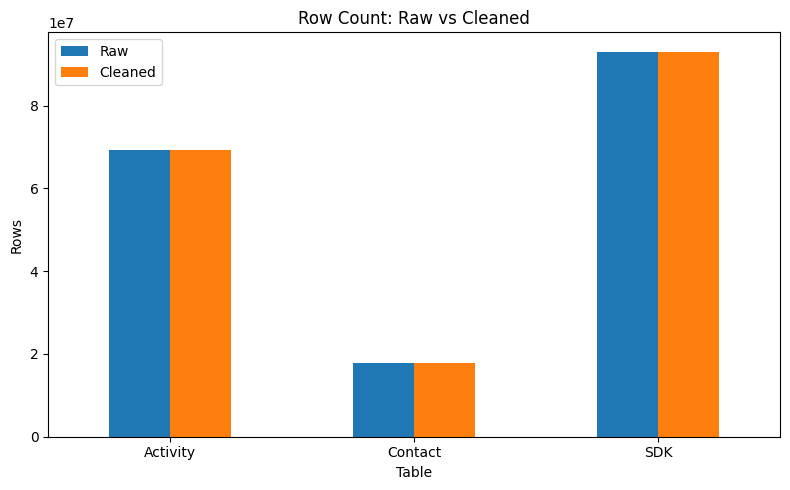

In [16]:
df_counts = pd.DataFrame({
    "Table": ["Activity", "Contact", "SDK"],
    "Raw": [
        con.execute("SELECT COUNT(*) FROM activity_clean").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM contact_clean").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM sdk_download_clean").fetchone()[0]
    ],
    "Cleaned": [
        con.execute("SELECT COUNT(*) FROM activity_final").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM contact_final").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM sdk_download_final").fetchone()[0]
    ]
})

display(df_counts)

df_counts.set_index("Table").plot(kind="bar", figsize=(8, 5))
plt.title("Row Count: Raw vs Cleaned")
plt.ylabel("Rows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Missing Values Before and After Cleaning

These comparisons show how the cleaning steps affected key missing-value patterns in the activity and contact datasets.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Raw,Cleaned
dev_contact,25.0,0.0
activity_date,3.0,0.0
activity_id,20.0,0.0


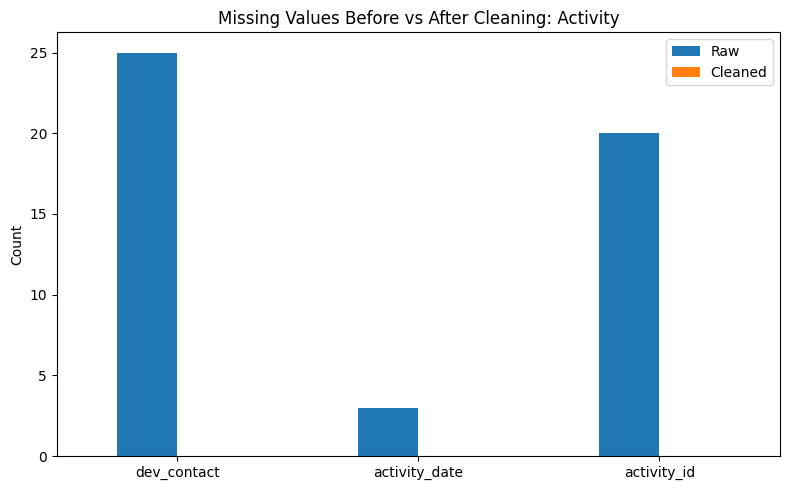

In [17]:
raw_nulls = con.execute("""
SELECT
    SUM(CASE WHEN dev_contact IS NULL OR TRIM(dev_contact) = '' THEN 1 ELSE 0 END) AS dev_contact,
    SUM(CASE WHEN activity_date IS NULL THEN 1 ELSE 0 END) AS activity_date,
    SUM(CASE WHEN activity_id IS NULL OR TRIM(activity_id) = '' THEN 1 ELSE 0 END) AS activity_id
FROM activity_clean
""").fetchdf()

clean_nulls = con.execute("""
SELECT
    SUM(CASE WHEN dev_contact IS NULL OR TRIM(dev_contact) = '' THEN 1 ELSE 0 END) AS dev_contact,
    SUM(CASE WHEN activity_date IS NULL THEN 1 ELSE 0 END) AS activity_date,
    SUM(CASE WHEN activity_id IS NULL OR TRIM(activity_id) = '' THEN 1 ELSE 0 END) AS activity_id
FROM activity_final
""").fetchdf()

df_nulls = pd.DataFrame({
    "Raw": raw_nulls.iloc[0],
    "Cleaned": clean_nulls.iloc[0]
})

display(df_nulls)

df_nulls.plot(kind="bar", figsize=(8, 5))
plt.title("Missing Values Before vs After Cleaning: Activity")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Raw,Cleaned
developer_id,0.0,0.0
country,0.0,0.0
organization_english_name,186.0,22.0
account_source,0.0,0.0


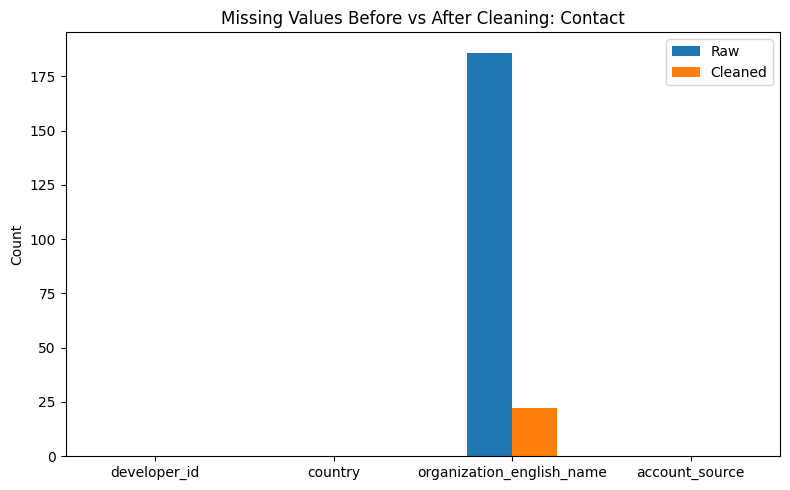

In [18]:
raw_contact_nulls = con.execute("""
SELECT
    SUM(CASE WHEN developer_id IS NULL OR TRIM(developer_id) = '' THEN 1 ELSE 0 END) AS developer_id,
    SUM(CASE WHEN country IS NULL OR TRIM(country) = '' THEN 1 ELSE 0 END) AS country,
    SUM(CASE WHEN organization_english_name IS NULL OR TRIM(organization_english_name) = '' THEN 1 ELSE 0 END) AS organization_english_name,
    SUM(CASE WHEN account_source IS NULL OR TRIM(account_source) = '' THEN 1 ELSE 0 END) AS account_source
FROM contact_clean
""").fetchdf()

clean_contact_nulls = con.execute("""
SELECT
    SUM(CASE WHEN developer_id IS NULL OR TRIM(developer_id) = '' THEN 1 ELSE 0 END) AS developer_id,
    SUM(CASE WHEN country IS NULL OR TRIM(country) = '' THEN 1 ELSE 0 END) AS country,
    SUM(CASE WHEN organization_english_name IS NULL OR TRIM(organization_english_name) = '' THEN 1 ELSE 0 END) AS organization_english_name,
    SUM(CASE WHEN account_source IS NULL OR TRIM(account_source) = '' THEN 1 ELSE 0 END) AS account_source
FROM contact_final
""").fetchdf()

df_contact_nulls = pd.DataFrame({
    "Raw": raw_contact_nulls.iloc[0],
    "Cleaned": clean_contact_nulls.iloc[0]
})

display(df_contact_nulls)

df_contact_nulls.plot(kind="bar", figsize=(8, 5))
plt.title("Missing Values Before vs After Cleaning: Contact")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Activity Score Validation

The following plots compare the activity score distribution before and after cleaning.

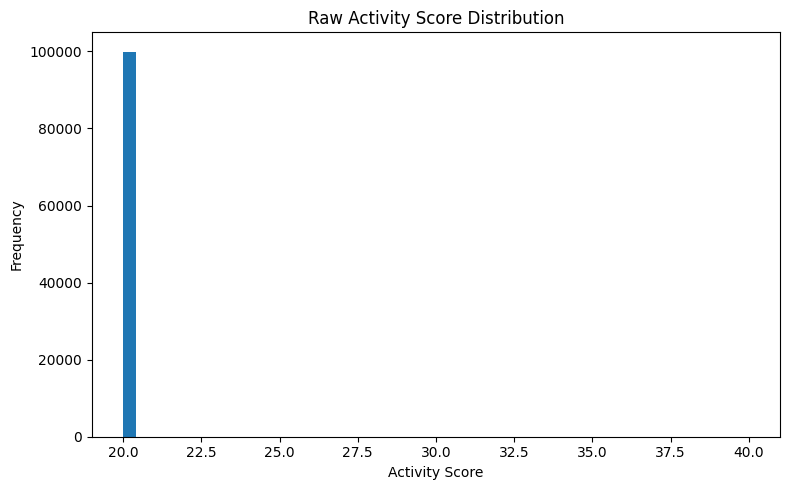

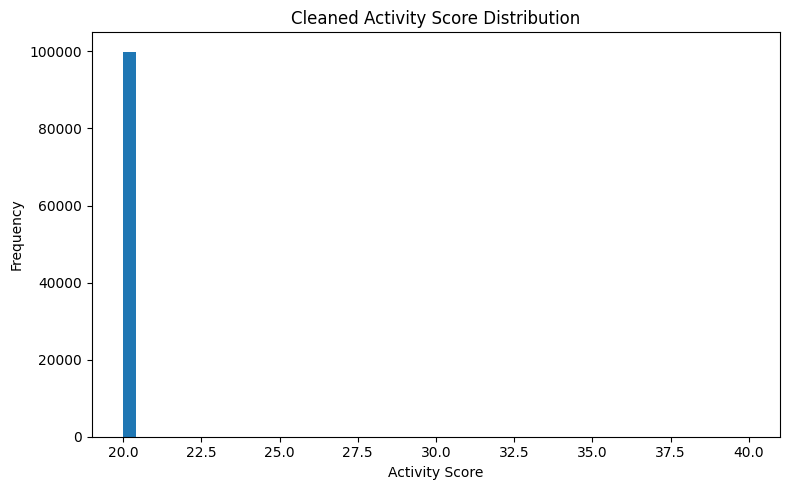

In [19]:
raw_scores = con.execute("""
SELECT TRY_CAST(activity_score AS DOUBLE) AS activity_score
FROM activity_clean
WHERE TRY_CAST(activity_score AS DOUBLE) IS NOT NULL
LIMIT 100000
""").fetchdf()

clean_scores = con.execute("""
SELECT activity_score
FROM activity_final
WHERE activity_score IS NOT NULL
LIMIT 100000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(raw_scores["activity_score"], bins=50)
plt.title("Raw Activity Score Distribution")
plt.xlabel("Activity Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(clean_scores["activity_score"], bins=50)
plt.title("Cleaned Activity Score Distribution")
plt.xlabel("Activity Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

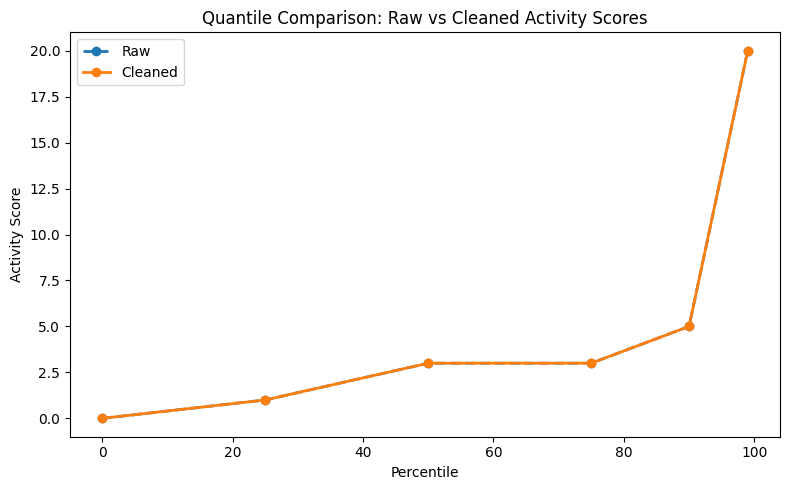

In [20]:
raw_q = con.execute("""
SELECT
    QUANTILE_CONT(TRY_CAST(activity_score AS DOUBLE), 0.00) AS p0,
    QUANTILE_CONT(TRY_CAST(activity_score AS DOUBLE), 0.25) AS p25,
    QUANTILE_CONT(TRY_CAST(activity_score AS DOUBLE), 0.50) AS p50,
    QUANTILE_CONT(TRY_CAST(activity_score AS DOUBLE), 0.75) AS p75,
    QUANTILE_CONT(TRY_CAST(activity_score AS DOUBLE), 0.90) AS p90,
    QUANTILE_CONT(TRY_CAST(activity_score AS DOUBLE), 0.99) AS p99
FROM activity_clean
WHERE TRY_CAST(activity_score AS DOUBLE) IS NOT NULL
""").fetchdf()

clean_q = con.execute("""
SELECT
    QUANTILE_CONT(activity_score, 0.00) AS p0,
    QUANTILE_CONT(activity_score, 0.25) AS p25,
    QUANTILE_CONT(activity_score, 0.50) AS p50,
    QUANTILE_CONT(activity_score, 0.75) AS p75,
    QUANTILE_CONT(activity_score, 0.90) AS p90,
    QUANTILE_CONT(activity_score, 0.99) AS p99
FROM activity_final
WHERE activity_score IS NOT NULL
""").fetchdf()

percentiles = [0, 25, 50, 75, 90, 99]

plt.figure(figsize=(8, 5))
plt.plot(percentiles, raw_q.values[0], marker="o", linestyle="--", linewidth=2, label="Raw")
plt.plot(percentiles, clean_q.values[0], marker="o", linestyle="-", linewidth=2, label="Cleaned")
plt.title("Quantile Comparison: Raw vs Cleaned Activity Scores")
plt.xlabel("Percentile")
plt.ylabel("Activity Score")
plt.legend()
plt.tight_layout()
plt.show()

### Activity Frequency Comparison

These charts compare the most common activity labels before and after cleaning.

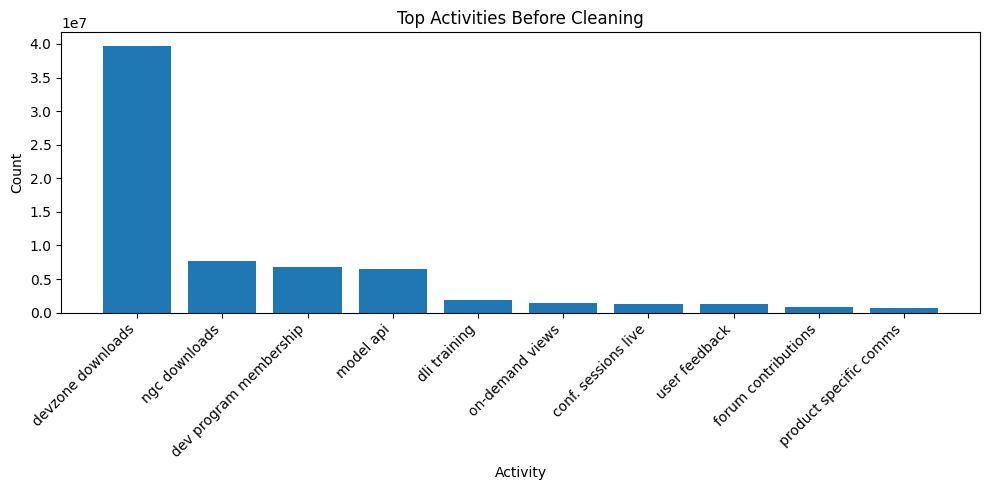

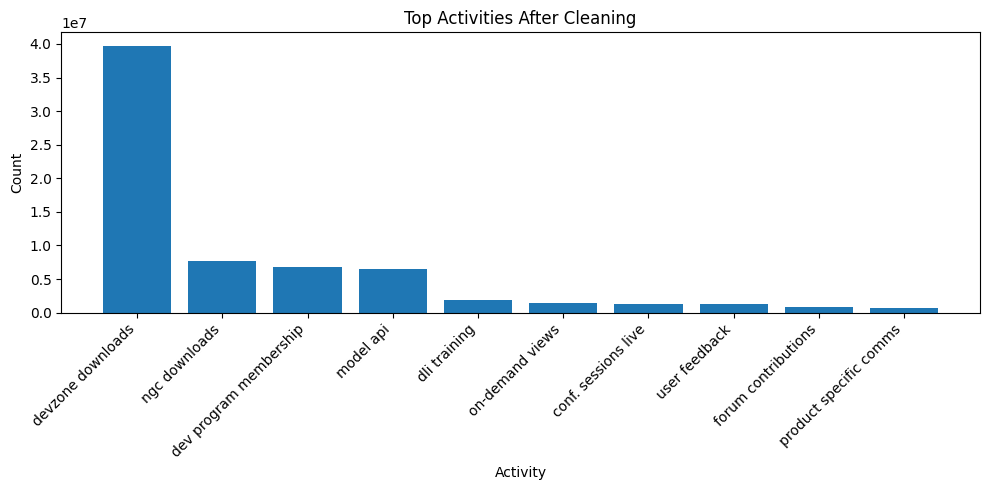

In [21]:
raw_cat = con.execute("""
SELECT
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity, 'unknown')), '\s+', ' ')) AS activity,
    COUNT(*) AS cnt
FROM activity_clean
GROUP BY 1
ORDER BY cnt DESC
LIMIT 10
""").fetchdf()

clean_cat = con.execute("""
SELECT
    activity,
    COUNT(*) AS cnt
FROM activity_final
GROUP BY 1
ORDER BY cnt DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10, 5))
plt.bar(raw_cat["activity"], raw_cat["cnt"])
plt.title("Top Activities Before Cleaning")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(clean_cat["activity"], clean_cat["cnt"])
plt.title("Top Activities After Cleaning")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### SDK Download Validation

The following plots compare SDK download count distributions and top source labels before and after cleaning.

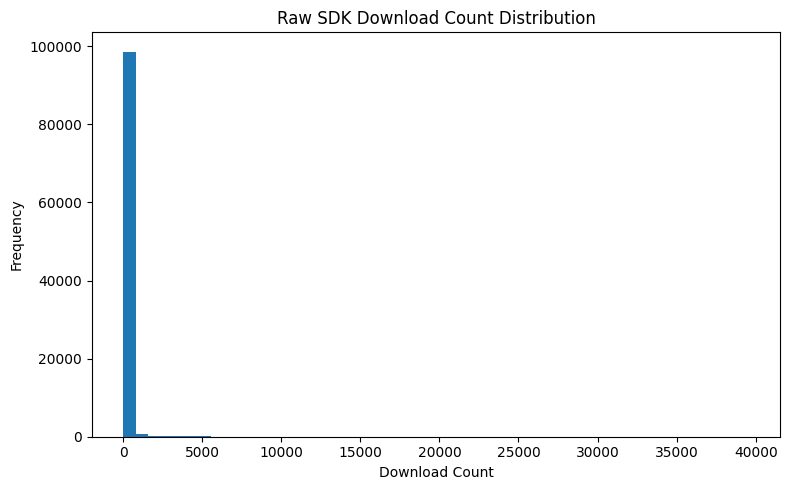

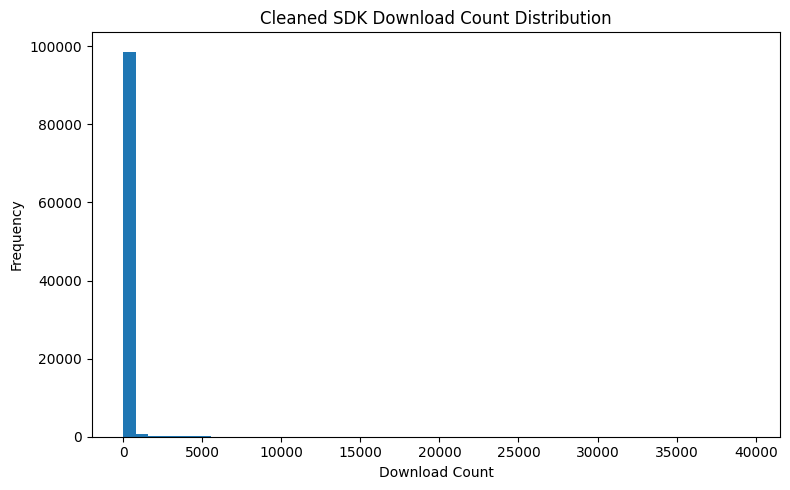

In [22]:
raw_sdk = con.execute("""
SELECT download_count
FROM sdk_download_clean
WHERE download_count IS NOT NULL
LIMIT 100000
""").fetchdf()

clean_sdk = con.execute("""
SELECT download_count
FROM sdk_download_final
WHERE download_count IS NOT NULL
LIMIT 100000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(raw_sdk["download_count"], bins=50)
plt.title("Raw SDK Download Count Distribution")
plt.xlabel("Download Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(clean_sdk["download_count"], bins=50)
plt.title("Cleaned SDK Download Count Distribution")
plt.xlabel("Download Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

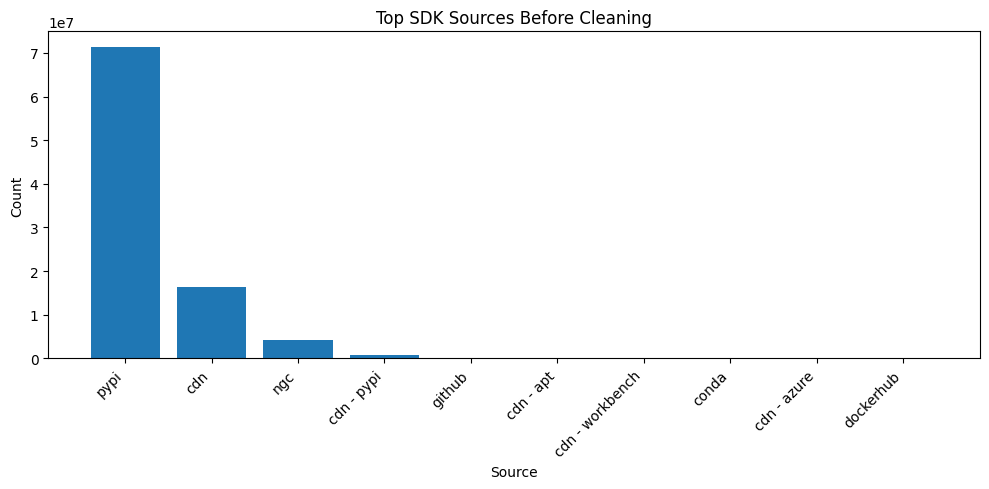

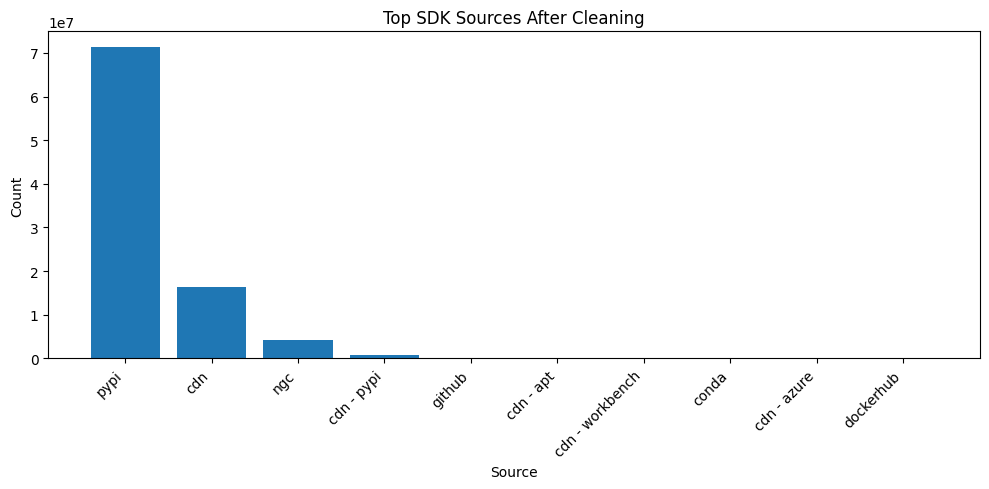

In [23]:
raw_sources = con.execute("""
SELECT
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(source, 'unknown')), '\s+', ' ')) AS source,
    COUNT(*) AS cnt
FROM sdk_download_clean
GROUP BY 1
ORDER BY cnt DESC
LIMIT 10
""").fetchdf()

clean_sources = con.execute("""
SELECT
    source,
    COUNT(*) AS cnt
FROM sdk_download_final
GROUP BY 1
ORDER BY cnt DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10, 5))
plt.bar(raw_sources["source"], raw_sources["cnt"])
plt.title("Top SDK Sources Before Cleaning")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(clean_sources["source"], clean_sources["cnt"])
plt.title("Top SDK Sources After Cleaning")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Contact Distribution Check

This chart provides a quick view of the most represented countries in the cleaned contact table.

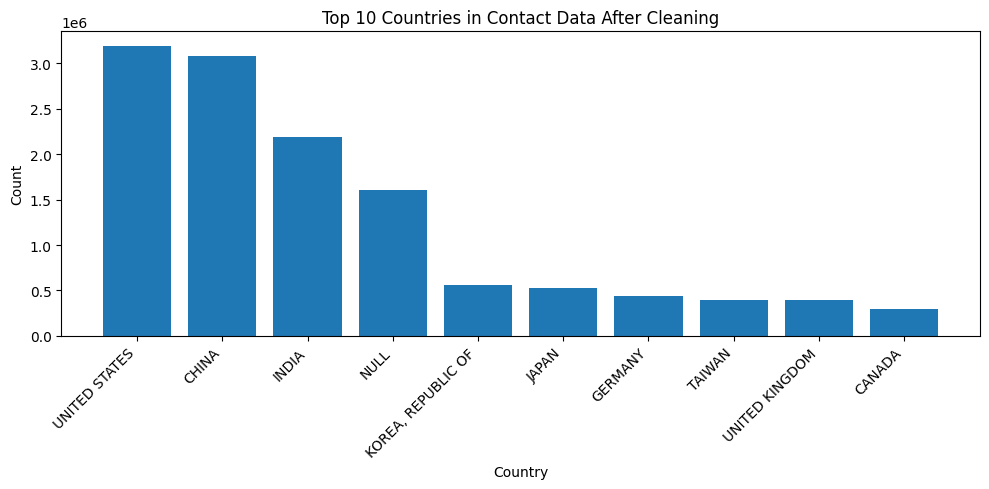

In [24]:
contact_country = con.execute("""
SELECT country, COUNT(*) AS cnt
FROM contact_final
GROUP BY country
ORDER BY cnt DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10, 5))
plt.bar(contact_country["country"], contact_country["cnt"])
plt.title("Top 10 Countries in Contact Data After Cleaning")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Final Anomaly Check

This final check compares raw and cleaned datasets for invalid activity scores and negative SDK download counts.

In [25]:
display(con.execute("""
SELECT
    'raw_activity' AS dataset,
    COUNT(*) AS anomalies
FROM activity_clean
WHERE TRY_CAST(activity_score AS DOUBLE) < 0
   OR TRY_CAST(activity_score AS DOUBLE) > 100

UNION ALL

SELECT
    'cleaned_activity' AS dataset,
    COUNT(*) AS anomalies
FROM activity_final
WHERE activity_score < 0 OR activity_score > 100

UNION ALL

SELECT
    'raw_sdk' AS dataset,
    COUNT(*) AS anomalies
FROM sdk_download_clean
WHERE download_count < 0

UNION ALL

SELECT
    'cleaned_sdk' AS dataset,
    COUNT(*) AS anomalies
FROM sdk_download_final
WHERE download_count < 0
""").fetchdf())

,dataset,anomalies
0,raw_activity,3
1,cleaned_activity,0
2,raw_sdk,132
3,cleaned_sdk,0


## Cleaning Summary

At this point, the project has produced cleaned versions of the three core datasets:

- `activity_final`
- `contact_final`
- `sdk_download_final`

These tables now provide the foundation for:

- joining activity with developer profiles
- building user-level behavioral features
- clustering developers into engagement cohorts
- evaluating how engagement may relate to adoption

The cleaning process emphasized standardization, score correction, and validation at each stage while preserving as many records as possible.

## Where Rows Were Lost

Row reductions occurred only where records were structurally unsuitable for analysis.

Examples include:

1. **Missing Developer Identifiers**
   - Rows with null or empty `developer_id` or `dev_contact` were excluded where those identifiers were required for reliable linkage.

2. **Invalid or Missing Dates**
   - Rows with missing activity dates or download dates were excluded where time-based analysis depends on valid dates.
   - Future dates were filtered out or converted to null depending on the dataset and field.

3. **Essential Table-Specific Validity Rules**
   - For example, SDK download rows required a valid `download_date`.
   - Contact rows required a valid `developer_id`.

No duplicate removal was applied in the final activity, contact, or SDK tables. Duplicate patterns were reported through validation instead.

## Why Limited Row Loss Is Expected

A small amount of row loss during cleaning is expected and necessary for data quality.

This mainly occurs when:

- identifiers required for joins are missing
- date fields are invalid for time-based analysis
- records fail basic structural validity checks

Rather than aggressively removing records, this notebook prioritizes:

- accuracy
- consistency
- interpretability
- auditability

Where possible, records are preserved and corrected instead of discarded.